# ETM5800 Assignment 2: Text Analytics on Sony WH-1000XM5 Reviews


In [9]:
!pip -q install gensim

import os, json, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix)
from gensim.models import Word2Vec

RANDOM_STATE = 42
os.makedirs('figures', exist_ok=True)
os.makedirs('tables', exist_ok=True)


In [10]:
# Load data
try:
    from google.colab import files
    uploaded = files.upload()
    DATA_PATH = next(iter(uploaded))
except Exception:
    DATA_PATH = 'cleaned_sony_my_wh1000xm5_reviews.csv'

df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
df['cleaned_text'] = df['cleaned_text'].fillna('').astype(str)
df['text'] = df['text'].fillna('').astype(str)
df['token_count'] = df['cleaned_text'].str.split().map(len)
print(f'Dataset: {df.shape[0]} reviews, {df.shape[1]} columns')
display(df[['text', 'cleaned_text', 'rating']].head(3))
print('\nRating distribution:')
display(df['rating'].value_counts().sort_index())


Dataset: 2125 reviews, 11 columns


,text,cleaned_text,rating
0,I've had these headphones for around three wee...,headphon around three week bought fed up pod f...,5
1,"No issues till now. But, it's still early, a w...",no issu till still earli week amaz sound great...,5
2,I bought these to replace a set of Airbuds for...,bought replac set airbud comfort sound qualiti...,4



Rating distribution:


rating
1     154
2      56
3     122
4     320
5    1473
Name: count, dtype: int64

In [11]:
# TF-IDF representation
tfidf = TfidfVectorizer(
    ngram_range=(1, 2), min_df=3, max_df=0.90,
    max_features=5000, sublinear_tf=True
)
X_tfidf = tfidf.fit_transform(df['cleaned_text'])

# Inspect top TF-IDF terms
terms = np.array(tfidf.get_feature_names_out())
mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()
top = pd.DataFrame({
    'term': terms[mean_tfidf.argsort()[-20:][::-1]],
    'mean_tfidf': np.sort(mean_tfidf)[-20:][::-1]
})
print(f'TF-IDF matrix: {X_tfidf.shape}')

# Word2Vec dense embeddings
# Train on cleaned review corpus, then create document vectors
tokenized_reviews = df['cleaned_text'].apply(lambda x: x.split()).tolist()

w2v_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100, window=5, min_count=2,
    sg=1, negative=10, workers=4,
    seed=RANDOM_STATE, epochs=30
)

# TF-IDF weighted document vectors (more informative terms contribute more)
idf_values = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))

def tfidf_weighted_w2v(tokens, model, idf_values, vector_size=100):
    vectors, weights = [], []
    for token in tokens:
        if token in model.wv and token in idf_values:
            vectors.append(model.wv[token])
            weights.append(idf_values[token])
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.average(np.array(vectors), axis=0, weights=np.array(weights))

X_w2v = np.vstack([
    tfidf_weighted_w2v(tokens, w2v_model, idf_values)
    for tokens in tokenized_reviews
])

print(f'Word2Vec document vectors: {X_w2v.shape}')
print(f'Vocabulary size: {len(w2v_model.wv)}')
print(f'Similar to "good": {[w for w, _ in w2v_model.wv.most_similar("good", topn=5)]}')


TF-IDF matrix: (2125, 5000)
Word2Vec document vectors: (2125, 100)
Vocabulary size: 2503
Similar to "good": ['great', 'immens', 'qualiti', 'confort', 'suppress']


In [12]:
# LDA topic modelling
topic_stopwords = [
    'headphon','headphone','soni','sony','xm5','wh','1000xm5',
    'use','used','using','bought','buy','purchas','purchase',
    'ago','week','month','year','day','one','two',
    'me','my','do','did','which','than','all','also',
    'very','still','just','really','much','thing','get','got','make','made'
]

count_vec = CountVectorizer(
    min_df=5, max_df=0.88, max_features=1500,
    ngram_range=(1, 2), stop_words=topic_stopwords
)
X_counts = count_vec.fit_transform(df['cleaned_text'])

lda = LatentDirichletAllocation(
    n_components=5, max_iter=30,
    learning_method='batch', random_state=RANDOM_STATE
)
doc_topic = lda.fit_transform(X_counts)
vocab = np.array(count_vec.get_feature_names_out())

manual_labels = {
    1: 'Comparisons and fit trade-offs',
    2: 'General quality satisfaction',
    3: 'Reliability and connectivity failures',
    4: 'ANC, music listening and long-use comfort',
    5: 'Advocacy and premium audio satisfaction'
}

rows = []
for i, weights in enumerate(lda.components_, start=1):
    top_idx = weights.argsort()[-10:][::-1]
    print(f'Topic {i} ({manual_labels[i]}): {", ".join(vocab[top_idx])}')
    for rank, idx in enumerate(top_idx, start=1):
        rows.append({
            'topic_id': i, 'label': manual_labels[i],
            'rank': rank, 'term': vocab[idx], 'weight': weights[idx]
        })

topic_terms = pd.DataFrame(rows)
display(topic_terms.head(20))


Topic 1 (Comparisons and fit trade-offs): not, sound, good, better, like, ear, more, nois, qualiti, onli
Topic 2 (General quality satisfaction): sound, good, qualiti, great, sound qualiti, comfort, easi, best, love, anc
Topic 3 (Reliability and connectivity failures): not, issu, off, work, after, turn, no, connect, tri, turn off
Topic 4 (ANC, music listening and long-use comfort): nois, cancel, nois cancel, sound, music, listen, comfort, work, great, featur
Topic 5 (Advocacy and premium audio satisfaction): sound, qualiti, nois, cancel, nois cancel, sound qualiti, great, recommend, love, amaz


,topic_id,label,rank,term,weight
0,1,Comparisons and fit trade-offs,1,not,407.931939
1,1,Comparisons and fit trade-offs,2,sound,208.366590
2,1,Comparisons and fit trade-offs,3,good,195.335142
3,1,Comparisons and fit trade-offs,4,better,188.389403
4,1,Comparisons and fit trade-offs,5,like,182.883963
5,1,Comparisons and fit trade-offs,6,ear,172.577884
6,1,Comparisons and fit trade-offs,7,more,160.022403
7,1,Comparisons and fit trade-offs,8,nois,133.114366
8,1,Comparisons and fit trade-offs,9,qualiti,130.501639
9,1,Comparisons and fit trade-offs,10,onli,128.027260


,Comparisons and fit trade-offs,General quality satisfaction,Reliability and connectivity failures,"ANC, music listening and long-use comfort",Advocacy and premium audio satisfaction
rating_group,,,,,
High (4-5),0.186229,0.212615,0.082045,0.248528,0.270583
Low (1-2),0.220008,0.052406,0.577514,0.088630,0.061442
Neutral (3),0.373754,0.127446,0.237033,0.140618,0.121149


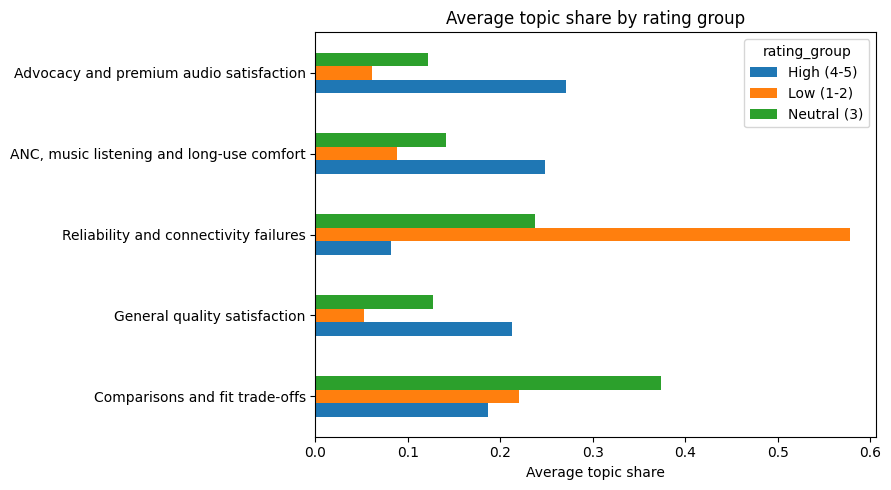

In [13]:
# Topic share by rating group
doc_topics = pd.DataFrame(
    doc_topic, columns=[f'Topic {i}' for i in range(1, 6)]
)
doc_topics['dominant_topic'] = doc_topics.idxmax(axis=1)
doc_topics['rating_group'] = np.select(
    [df.rating <= 2, df.rating == 3, df.rating >= 4],
    ['Low (1-2)', 'Neutral (3)', 'High (4-5)'],
    default='Unknown'
)

share_by_group = doc_topics.groupby('rating_group')[
    [f'Topic {i}' for i in range(1, 6)]
].mean()
share_by_group.columns = [manual_labels[i] for i in range(1, 6)]

display(share_by_group)
share_by_group.T.plot(kind='barh', figsize=(9, 5))
plt.title('Average topic share by rating group')
plt.xlabel('Average topic share')
plt.tight_layout()
plt.show()


In [14]:
# Supervised prediction: compare TF-IDF vs Word2Vec
model_df = df[df.rating.isin([1, 2, 4, 5])].copy()
model_df['complaint_risk'] = (model_df.rating <= 2).astype(int)

# Stratified split
train_idx, test_idx = train_test_split(
    model_df.index, test_size=0.25,
    random_state=RANDOM_STATE, stratify=model_df['complaint_risk']
)

X_train_text = model_df.loc[train_idx, 'cleaned_text']
X_test_text = model_df.loc[test_idx, 'cleaned_text']
y_train = model_df.loc[train_idx, 'complaint_risk']
y_test = model_df.loc[test_idx, 'complaint_risk']
X_train_w2v = X_w2v[train_idx]
X_test_w2v = X_w2v[test_idx]

# Model 1: TF-IDF + Logistic Regression
tfidf_logit = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2), min_df=3, max_df=0.90,
        max_features=5000, sublinear_tf=True
    )),
    ('logit', LogisticRegression(
        max_iter=1200, class_weight='balanced',
        solver='liblinear', random_state=RANDOM_STATE
    ))
])

# Model 2: Word2Vec + Logistic Regression
w2v_logit = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(
        max_iter=1200, class_weight='balanced',
        solver='liblinear', random_state=RANDOM_STATE
    ))
])

models = {
    'TF-IDF + Logistic Regression': (tfidf_logit, X_train_text, X_test_text),
    'Word2Vec + Logistic Regression': (w2v_logit, X_train_w2v, X_test_w2v)
}

metrics = []
for name, (model, X_train_input, X_test_input) in models.items():
    model.fit(X_train_input, y_train)
    pred = model.predict(X_test_input)
    proba = model.predict_proba(X_test_input)[:, 1]
    
    metrics.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'complaint_precision': precision_score(y_test, pred, zero_division=0),
        'complaint_recall': recall_score(y_test, pred, zero_division=0),
        'complaint_f1': f1_score(y_test, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, proba)
    })
    
    print(f'\n{name}')
    print(confusion_matrix(y_test, pred))
    print(classification_report(
        y_test, pred,
        target_names=['satisfied', 'complaint_risk'],
        zero_division=0
    ))

metrics = pd.DataFrame(metrics)
display(metrics)



TF-IDF + Logistic Regression
[[429  19]
 [ 12  41]]
                precision    recall  f1-score   support

     satisfied       0.97      0.96      0.97       448
complaint_risk       0.68      0.77      0.73        53

      accuracy                           0.94       501
     macro avg       0.83      0.87      0.85       501
  weighted avg       0.94      0.94      0.94       501


Word2Vec + Logistic Regression
[[404  44]
 [  9  44]]
                precision    recall  f1-score   support

     satisfied       0.98      0.90      0.94       448
complaint_risk       0.50      0.83      0.62        53

      accuracy                           0.89       501
     macro avg       0.74      0.87      0.78       501
  weighted avg       0.93      0.89      0.91       501



,model,accuracy,complaint_precision,complaint_recall,complaint_f1,roc_auc
0,TF-IDF + Logistic Regression,0.938124,0.683333,0.773585,0.725664,0.958389
1,Word2Vec + Logistic Regression,0.894212,0.500000,0.830189,0.624113,0.933078


In [15]:
# Extract key terms from TF-IDF logistic regression
best = tfidf_logit
terms = np.array(best.named_steps['tfidf'].get_feature_names_out())
coefs = best.named_steps['logit'].coef_[0]

drivers = pd.concat([
    pd.DataFrame({
        'term': terms[np.argsort(coefs)[-15:][::-1]],
        'coefficient': np.sort(coefs)[-15:][::-1],
        'direction': 'higher complaint risk'
    }),
    pd.DataFrame({
        'term': terms[np.argsort(coefs)[:15]],
        'coefficient': np.sort(coefs)[:15],
        'direction': 'lower complaint risk'
    })
])
display(drivers)

# Save results
metrics.to_csv('tables/supervised_model_metrics.csv', index=False)
topic_terms.to_csv('tables/lda_topic_terms.csv', index=False)
drivers.to_csv('tables/tfidf_logistic_key_terms.csv', index=False)


,term,coefficient,direction
0,warranti,2.494816,higher complaint risk
1,not,2.488252,higher complaint risk
2,broke,2.143358,higher complaint risk
3,support,2.087392,higher complaint risk
4,no,1.968299,higher complaint risk
5,poor,1.902327,higher complaint risk
6,return,1.846163,higher complaint risk
7,servic,1.779570,higher complaint risk
8,after,1.718369,higher complaint risk
9,soni,1.698153,higher complaint risk
